In [166]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [167]:
class BatsmanState(TypedDict):
    runs  : int
    balls : int
    fours : int
    sixes : int

    st_rate : float
    runs_per_ball : float
    boundry_runs : int
    boundry_ball_percent : float
    summary = str


In [168]:
graph = StateGraph(BatsmanState)

In [169]:
def strike_rate(state: BatsmanState):
    strr = (state["runs"]) / (state["balls"]) * 100
    return {'st_rate': strr}
    

In [170]:
def runs_per_ball(state: BatsmanState):
    rpb = (state["runs"] / state["balls"])
    return {"runs_per_ball": rpb}

In [171]:
def boundry_runs(state: BatsmanState):
    br = (state["fours"] * 4) + (state["sixes"] * 6)
    return {"boundry_runs": br}

In [172]:
def boundry_ball_percent(state: BatsmanState):
    bbp = (state["fours"] + state["sixes"]) / state["balls"] * 100
    return {"boundry_ball_percent": bbp}

In [173]:
def summary(state:BatsmanState):
    summ = f"""Runs: {state["runs"]} \n
    Balls: {state["balls"]} \n
    Fours: {state["fours"]}\n
    Sixes: {state["sixes"]}\n
    Strike Rate: {state["st_rate"]}\n
    Runs per Ball: {state["runs_per_ball"]}\n
    Boundry Runs: {state["boundry_runs"]}\n
    Boundry Ball Percent: {state["boundry_ball_percent"]}\n
    """
    return {"summary": summ}

In [174]:
# Add nodes
graph.add_node("strike_rate", strike_rate)
graph.add_node("runs_per_ball", runs_per_ball)
graph.add_node("boundry_runs", boundry_runs)
graph.add_node("boundry_ball_percent", boundry_ball_percent)
graph.add_node("summary", summary)


In [175]:
# Add Edges
graph.add_edge(START, "strike_rate")
graph.add_edge(START, "runs_per_ball")
graph.add_edge(START, "boundry_runs")
graph.add_edge(START, "boundry_ball_percent")

graph.add_edge("strike_rate", "summary")
graph.add_edge("runs_per_ball", "summary")
graph.add_edge("boundry_runs", "summary")
graph.add_edge("boundry_ball_percent", "summary")

graph.add_edge("summary", END)

In [176]:
# compile workflow
workflow = graph.compile()


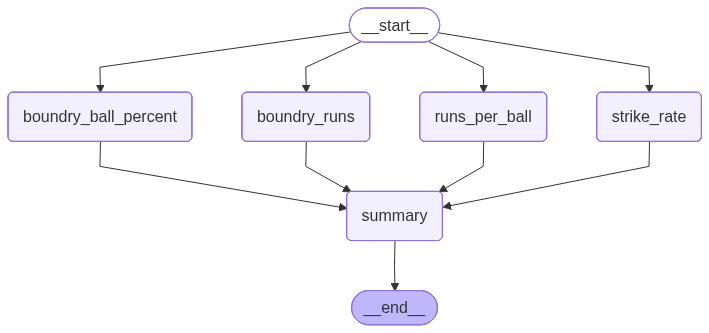

In [177]:
graph.compile()

In [180]:
# Execute the graph
initial_state = {
    "runs": 120,
    "balls": 80,
    "fours": 10,
    "sixes": 5
}

workflow.invoke(initial_state)
# print(final_state)

{'runs': 120,
 'balls': 80,
 'fours': 10,
 'sixes': 5,
 'st_rate': 150.0,
 'runs_per_ball': 1.5,
 'boundry_runs': 70,
 'boundry_ball_percent': 18.75}

In [179]:
# from Ipython import Image
